# Task 5: Disease Gene Prioritization

This notebook demonstrates **Task 5** of the scGVP downstream analysis pipeline: identifying the most important genes driving a drug's perturbation response, integrating both transcriptomic evidence and protein–protein interaction (PPI) network topology.

## Rationale
Ranking genes by their response to a disease-relevant drug can reveal therapeutic targets and biomarkers. scGVP combines three complementary signals:
- **Expression signal**: |log2 fold change| between control and perturbed cells
- **Consistency signal**: low variability across samples (inverse coefficient of variation)
- **Statistical significance**: −log10(adjusted p-value) from t-tests

This composite score is then boosted by each gene's centrality in the STRING PPI network.

## Scoring Formula
$$\text{Importance} = 0.5 \times |\log_2\text{FC}|_{\text{norm}} + 0.2 \times \text{Consistency}_{\text{norm}} + 0.3 \times \text{Significance}_{\text{norm}}$$
$$\text{Final Score} = 0.7 \times \text{Importance} + 0.3 \times \text{Network Score}$$

## Workflow
1. Load model and LINCS dataset
2. Process reference dataset
3. Prioritise genes for a single disease-relevant drug
4. Visualise priority scores and score composition
5. Batch analysis across multiple drugs

## Outputs
- `drug_*_gene_priority.csv` — ranked gene list per drug
- `drug_*_visualization.png` — bar chart + score composition
- `summary.csv` — batch analysis summary across all drugs

## 1. Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import networkx as nx

from model import GINVAE
from dataset import ChunkedGeneGraphDataset
from task5 import DiseaseGenePrioritization

print(f"PyTorch: {torch.__version__}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.9.0.dev20250827+cu129
Device : cuda


## 2. Configuration

Datasets and model weights are available at:  
**https://huggingface.co/datasets/Mike2481/Dataset4scGVP/tree/main**

In [2]:
MODEL_PATH  = '../src/best_gin_vae_model_node_level.pth'
LINCS_PATH  = '../lincs/merged_all_965_with_morgan.h5ad'
TAHOE_PATHS = [f'../minitahoe/p{i}_with_morgan.h5ad' for i in range(1, 15)]
REF_CACHE   = './output/reference_latents.pkl'
SAVE_DIR    = './output/task2_drug_network'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('./output', exist_ok=True)

# Number of top genes to return
TOP_K = 50
# Number of drugs for batch analysis
N_DRUGS_BATCH = 5

## 3. Load Model

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GINVAE(input_dim=1, hidden_dim=300, latent_dim=100, num_layers=2).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"Model loaded on {device}")

Model loaded on cuda


## 4. Load Data

In [4]:
lincs_adata = sc.read_h5ad(LINCS_PATH)
print(f"LINCS dataset: {lincs_adata.shape[0]} cells × {lincs_adata.shape[1]} genes")
print(f"Gene names (first 5): {list(lincs_adata.var_names[:5])}")
print(f"Unique drugs : {lincs_adata.obs['canonical_smiles'].nunique()}")

lincs_dataset = ChunkedGeneGraphDataset([LINCS_PATH], split='test')
print(f"Dataset samples: {len(lincs_dataset)}")

LINCS dataset: 157138 cells × 965 genes
Gene names (first 5): ['GNPDA1', 'CDH3', 'HDAC6', 'PARP2', 'MAMLD1']
Unique drugs : 8316
Found 32 chunks with 157138 total samples
Dataset samples: 157138


## 5. Process Reference Dataset

In [5]:
model.process_reference_dataset(
    x_ref_dataset=lincs_dataset,
    save_path=REF_CACHE,
    force_reprocess=False
)
print("Reference dataset ready.")

Loading existing processed data from ./output/reference_latents.pkl
Loaded reference data metadata from ./output/reference_latents.pkl
Total samples available: 157138
Loading data from chunks...


Loading chunks: 100%|██████████| 16/16 [00:02<00:00,  6.97it/s, file=chunk_15.pkl]


Loaded and filtered 157138 samples from chunks
Computing biological context from 78569 control and 78569 perturb samples
Extracting graph-level latent representations...


Processing perturb samples: 100%|██████████| 78569/78569 [00:01<00:00, 53659.66it/s]


Computing mean representations...
References computed successfully.
Control ref shape: torch.Size([1, 100]), norm: 3.5154
perturb ref shape: torch.Size([1, 100]), norm: 3.5215
Biological context norm: 0.0068
Reference dataset ready.


## 6. Initialise DiseaseGenePrioritization

In [6]:
task5 = DiseaseGenePrioritization(model, device)
print("DiseaseGenePrioritization initialised.")

DiseaseGenePrioritization initialised.


## 7. Prioritise Genes for a Single Drug

We select a disease-relevant drug and compute gene importance scores combined with STRING network centrality.

In [7]:
# Select the first drug as the disease-relevant drug
ptrb_col = 'canonical_smiles'
disease_drug = lincs_adata.obs[ptrb_col].unique()[0]
print(f"Disease drug SMILES: {disease_drug[:70]}...")

gene_priority, gene_network = task5.prioritize_disease_genes(
    adata=lincs_adata,
    disease_condition=disease_drug,
    test_dataset=lincs_dataset,
    top_k=TOP_K
)

if gene_priority is not None:
    print(f"\n✓ Gene prioritization complete. Top 10 genes:")
    display(gene_priority.head(10)[['gene', 'final_score', 'importance_score', 'log2fc', 'network_score']])
else:
    print("Gene prioritization failed — check that the drug has control and perturbed samples.")

Disease drug SMILES: BrCC(=O)NCCc1ccc2ccccc2c1...

Prioritizing genes for disease condition: BrCC(=O)NCCc1ccc2ccccc2c1
Using 1 control and 1 perturbed samples
Computing gene importance from 1 control and 1 perturbed samples...
  Top gene: DNAJA3 (score: 1.0000)
  Score range: [0.0000, 1.0000]

Integrating STRING network for top 100 genes...
  Network: 45 nodes, 64 edges

✓ Gene prioritization completed
Top 5 prioritized genes:
  DNAJA3: final_score=0.7191, log2fc=-6.5633, network=0.0636
  EPHB2: final_score=0.6475, log2fc=5.5345, network=0.1907
  SPP1: final_score=0.6152, log2fc=-4.4432, network=0.4711
  GNAS: final_score=0.5542, log2fc=-4.8232, network=0.1327
  MAPK13: final_score=0.4964, log2fc=4.0935, network=0.1994

✓ Gene prioritization complete. Top 10 genes:


,gene,final_score,importance_score,log2fc,network_score
881,DNAJA3,0.719070,1.000000,-6.563275,0.063568
186,EPHB2,0.647477,0.843237,5.534525,0.190703
710,SPP1,0.615172,0.676935,-4.443174,0.471058
321,GNAS,0.554212,0.734851,-4.823250,0.132720
590,MAPK13,0.496368,0.623650,4.093500,0.199376
133,CRK,0.481329,0.570614,3.745450,0.272996
40,IKZF1,0.479787,0.545463,-3.580400,0.326544
749,TLR4,0.465150,0.414594,-2.721575,0.583114
879,MAP7,0.451460,0.617700,-4.054451,0.063568
550,ZNF586,0.404398,0.577711,3.792026,0.000000


## 8. Visualise Gene Prioritization

Two panels:
- **Left**: Ranked bar chart of top genes by final score
- **Right**: Stacked bar showing the contribution of expression-based vs. network-based scores

In [8]:
if gene_priority is not None:
    vis_path = os.path.join(SAVE_DIR, 'single_drug_gene_priority.png')
    task5.visualize_gene_prioritization(
        gene_importance=gene_priority,
        G=gene_network,
        top_k=20,
        save_path=vis_path
    )
    print(f"Visualisation saved to: {vis_path}")

    from IPython.display import Image
    Image(vis_path)

✓ Gene prioritization visualization saved to ./output/task2_drug_network/single_drug_gene_priority.png
✓ Gene network visualization saved to ./output/task2_drug_network/single_drug_gene_priority_network.png
Visualisation saved to: ./output/task2_drug_network/single_drug_gene_priority.png


## 9. Gene Priority Score Decomposition

Explore the contribution of each scoring component for the top 20 genes.

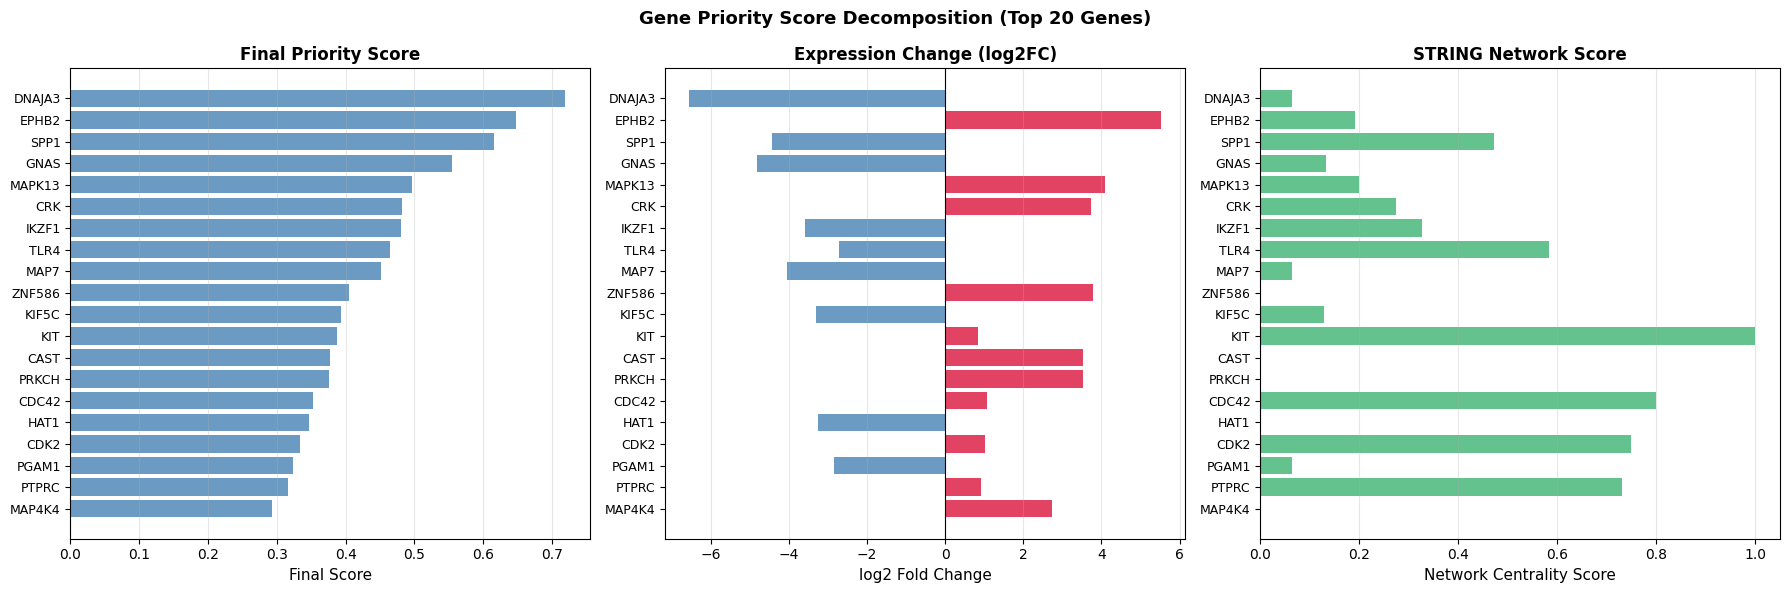

In [10]:
if gene_priority is not None:
    top20 = gene_priority.head(20)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    y_pos = np.arange(len(top20))

    # Final score
    axes[0].barh(y_pos, top20['final_score'], color='steelblue', alpha=0.8)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(top20['gene'], fontsize=9)
    axes[0].set_xlabel('Final Score', fontsize=11)
    axes[0].set_title('Final Priority Score', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    # log2FC direction
    colors_fc = ['crimson' if v > 0 else 'steelblue' for v in top20['log2fc']]
    axes[1].barh(y_pos, top20['log2fc'], color=colors_fc, alpha=0.8)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(top20['gene'], fontsize=9)
    axes[1].set_xlabel('log2 Fold Change', fontsize=11)
    axes[1].set_title('Expression Change (log2FC)', fontsize=12, fontweight='bold')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)

    # Network score
    axes[2].barh(y_pos, top20['network_score'], color='mediumseagreen', alpha=0.8)
    axes[2].set_yticks(y_pos)
    axes[2].set_yticklabels(top20['gene'], fontsize=9)
    axes[2].set_xlabel('Network Centrality Score', fontsize=11)
    axes[2].set_title('STRING Network Score', fontsize=12, fontweight='bold')
    axes[2].invert_yaxis()
    axes[2].grid(axis='x', alpha=0.3)

    plt.suptitle('Gene Priority Score Decomposition (Top 20 Genes)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'score_decomposition.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 10. Volcano-style Plot: log2FC vs. Final Score

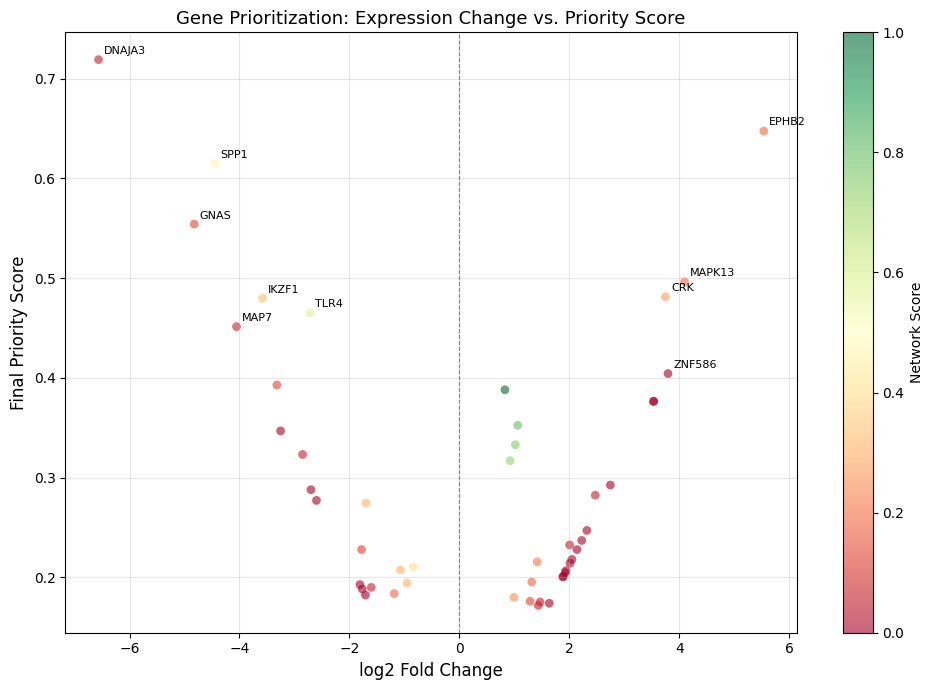

In [11]:
if gene_priority is not None:
    fig, ax = plt.subplots(figsize=(10, 7))

    sc_plot = ax.scatter(
        gene_priority['log2fc'],
        gene_priority['final_score'],
        c=gene_priority['network_score'],
        cmap='RdYlGn',
        alpha=0.6, s=40, edgecolors='none'
    )
    plt.colorbar(sc_plot, ax=ax, label='Network Score')

    # Label top 10 genes
    for _, row in gene_priority.head(10).iterrows():
        ax.annotate(
            row['gene'],
            (row['log2fc'], row['final_score']),
            fontsize=8,
            xytext=(4, 4), textcoords='offset points'
        )

    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('log2 Fold Change', fontsize=12)
    ax.set_ylabel('Final Priority Score', fontsize=12)
    ax.set_title('Gene Prioritization: Expression Change vs. Priority Score', fontsize=13)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'volcano_priority.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Batch Analysis — Multiple Drugs

Run gene prioritization across multiple drugs and aggregate the results.

In [12]:
batch_dir = os.path.join(SAVE_DIR, 'batch_results')

summary_df = task5.batch_prioritize_drugs(
    adata=lincs_adata,
    n_drugs=N_DRUGS_BATCH,
    save_dir=batch_dir
)

print("\nBatch Analysis Summary:")
display(summary_df)


Processing drug 1/5

Prioritizing genes for disease condition: BrCC(=O)NCCc1ccc2ccccc2c1
Using 1 control and 1 perturbed samples
Computing gene importance from 1 control and 1 perturbed samples...
  Top gene: DNAJA3 (score: 1.0000)
  Score range: [0.0000, 1.0000]

Integrating STRING network for top 100 genes...
  Network: 45 nodes, 64 edges

✓ Gene prioritization completed
Top 5 prioritized genes:
  DNAJA3: final_score=0.7191, log2fc=-6.5633, network=0.0636
  EPHB2: final_score=0.6475, log2fc=5.5345, network=0.1907
  SPP1: final_score=0.6152, log2fc=-4.4432, network=0.4711
  GNAS: final_score=0.5542, log2fc=-4.8232, network=0.1327
  MAPK13: final_score=0.4964, log2fc=4.0935, network=0.1994
✓ Gene prioritization visualization saved to ./output/task2_drug_network/batch_results/drug_1_visualization.png
✓ Gene network visualization saved to ./output/task2_drug_network/batch_results/drug_1_visualization_network.png

Processing drug 2/5

Prioritizing genes for disease condition: Brc1cc2OCOc

,drug_id,n_prioritized_genes,top_gene,top_score,network_available
0,BrCC(=O)NCCc1ccc2ccccc2c1,50,DNAJA3,0.719070,True
1,Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53,50,CALM3,0.730781,True
2,Brc1ccc(Cn2cncc2Cn2cc(C(=O)N3CCOCC3)c(c2)-c2cc...,50,TSC22D3,0.715452,True
3,Brc1ccc(cc1)-c1csc(n1)N1CCNCC1,50,RTN2,0.740088,True
4,Brc1cccc(Nc2ncnc3ccc(NC(=O)C=C)cc23)c1,50,CCNA2,0.729671,True


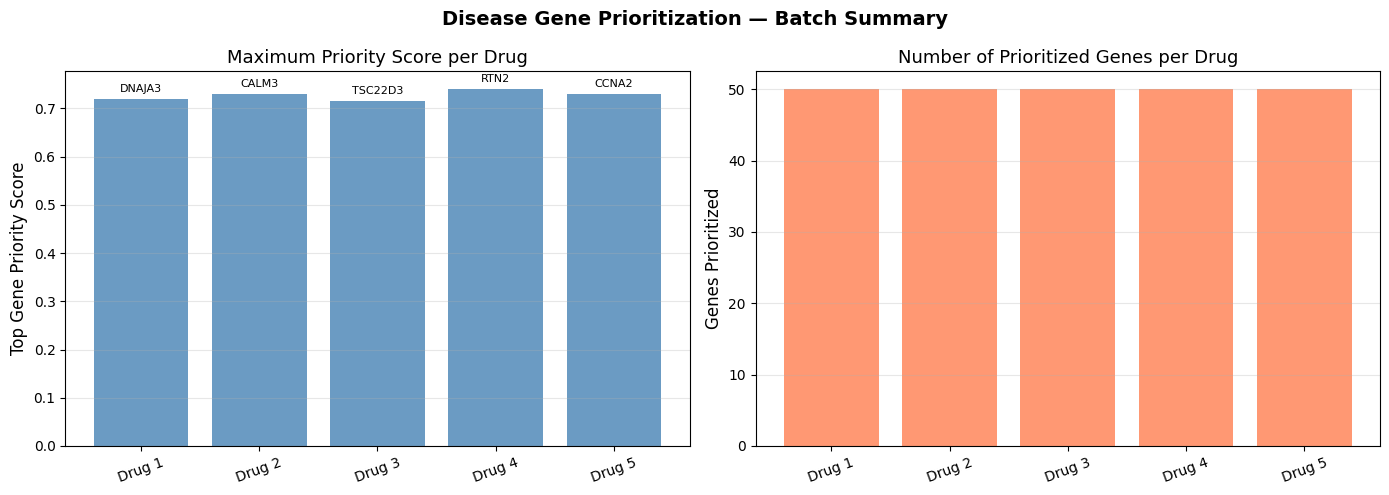

In [13]:
# Bar chart of top gene scores across drugs
if len(summary_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    drug_labels = [f"Drug {i+1}" for i in range(len(summary_df))]

    axes[0].bar(drug_labels, summary_df['top_score'], color='steelblue', alpha=0.8)
    axes[0].set_ylabel('Top Gene Priority Score', fontsize=12)
    axes[0].set_title('Maximum Priority Score per Drug', fontsize=13)
    for i, (label, score) in enumerate(zip(summary_df['top_gene'], summary_df['top_score'])):
        axes[0].text(i, score + 0.01, label, ha='center', va='bottom', fontsize=8)
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(drug_labels, summary_df['n_prioritized_genes'], color='coral', alpha=0.8)
    axes[1].set_ylabel('Genes Prioritized', fontsize=12)
    axes[1].set_title('Number of Prioritized Genes per Drug', fontsize=13)
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle('Disease Gene Prioritization — Batch Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'batch_summary.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 12. Save Single-Drug Results

In [14]:
if gene_priority is not None:
    out_path = os.path.join(SAVE_DIR, 'single_drug_gene_priority.csv')
    gene_priority.to_csv(out_path, index=False)
    print(f"Gene priority saved to: {out_path}")

print("\n" + "=" * 60)
print("Task 5: Disease Gene Prioritization — Summary")
print("=" * 60)
if gene_priority is not None:
    print(f"  Genes prioritized          : {len(gene_priority)}")
    print(f"  Top gene                   : {gene_priority.iloc[0]['gene']}")
    print(f"  Top gene score             : {gene_priority.iloc[0]['final_score']:.4f}")
    print(f"  Top gene log2FC            : {gene_priority.iloc[0]['log2fc']:.4f}")
    print(f"  Network available          : {gene_network is not None}")
print(f"\n  All outputs saved to: {SAVE_DIR}")

Gene priority saved to: ./output/task2_drug_network/single_drug_gene_priority.csv

Task 5: Disease Gene Prioritization — Summary
  Genes prioritized          : 50
  Top gene                   : DNAJA3
  Top gene score             : 0.7191
  Top gene log2FC            : -6.5633
  Network available          : True

  All outputs saved to: ./output/task2_drug_network
